# EletroSonic

## Ánalise de Fluxo Veicular em BH - Estudo de Demanda para EletroPosto

**Fonte:** Portal de Dados Abertos de BH — BHTrans (Contagens Volumétricas de Radares)

**Fonte:** Ministério dos Trasnportes - Frota de Veículos 2025

**URL:** http://servicosbhtrans.pbh.gov.br/Bhtrans/webservice/
https://abve.org.br/abve-data/bi-geografia-da-eletromobilidade/

**URL:** https://www.gov.br/transportes/pt-br/assuntos/transito/conteudo-Senatran/frota-de-veiculos-2025


---
## Objetivo 

Entender a frota de carros elérticos e hibridos em Belo Horizonte e Nova Lima

## Inicialização

In [20]:
import pandas as pd
import os
from matplotlib import pyplot as plt
import seaborn as sns
from funcao import prever_frota_eletrica
import plotly.express as px

In [21]:
# definir o caminho onde estão os arquivos
base_path = '/Users/laionbeltrao/Desktop/eletro_sonic/eletrosonic/planilhas/combustivel'

# lista para armazenar os dataframes
lista_dataframes = []

# iterar os 12 arquivos
for mes  in range(1,13):
    arquivo = os.path.join(base_path, f'{mes}-COMBUSTIVEL.xlsx')

    if os.path.exists(arquivo):
        df = pd.read_excel(arquivo)
        df['mes'] = mes
        lista_dataframes.append(df)
        print(f"Mês {mes} carregado: {len(df)} linhas")
    else:
        print(f"Arquivo do mês {mes} não encontrado: {arquivo}")

# concatenar todos os dataframes da lista
df_combustivel = pd.concat(lista_dataframes, ignore_index=True)

# salvar o resultado em uma nova planilha
df_combustivel.to_excel("planilha_consolidada.xlsx", index=False)

Mês 1 carregado: 52726 linhas
Mês 2 carregado: 52958 linhas
Mês 3 carregado: 53169 linhas
Mês 4 carregado: 53427 linhas
Mês 5 carregado: 53717 linhas
Mês 6 carregado: 53934 linhas
Mês 7 carregado: 54241 linhas
Mês 8 carregado: 54529 linhas
Mês 9 carregado: 54743 linhas
Mês 10 carregado: 54977 linhas
Mês 11 carregado: 55274 linhas
Mês 12 carregado: 55609 linhas


In [22]:
df_combustivel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649304 entries, 0 to 649303
Data columns (total 5 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   UF                   649304 non-null  object
 1   Município            649304 non-null  object
 2   Combustível Veículo  649304 non-null  object
 3   Qtd. Veículos        649304 non-null  int64 
 4   mes                  649304 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 24.8+ MB


In [23]:
df_combustivel.head()

,UF,Município,Combustível Veículo,Qtd. Veículos,mes
0,ACRE,ACRELANDIA,ALCOOL,59,1
1,ACRE,ACRELANDIA,ALCOOL/GASOLINA,2972,1
2,ACRE,ACRELANDIA,DIESEL,1112,1
3,ACRE,ACRELANDIA,GASOLINA,3934,1
4,ACRE,ACRELANDIA,GASOLINA/ALCOOL/GAS NATURAL,2,1


In [24]:
# adicionar coluna date
df_combustivel['data'] = pd.to_datetime(df_combustivel['mes'].astype(str) + '-2026', format='%m-%Y')

In [25]:
# alterar nome das colunas
df_combustivel.columns = ['uf','municipio','combustivel','qtd_veiculos','mes','data']

In [26]:
df_combustivel['combustivel'].unique()

array(['ALCOOL', 'ALCOOL/GASOLINA', 'DIESEL', 'GASOLINA',
       'GASOLINA/ALCOOL/GAS NATURAL', 'Sem Informação',
       'ELETRICO/FONTE EXTERNA', 'GASOL/GAS NATURAL COMBUSTIVEL',
       'GASOLINA/ALCOOL/ELETRICO', 'GASOLINA/ELETRICO', 'HIBRIDO PLUG-IN',
       'GASOLINA/GAS NATURAL VEICULAR', 'ALCOOL/GAS NATURAL COMBUSTIVEL',
       'DIESEL/ELETRICO', 'ELETRICO/FONTE INTERNA', 'HIBRIDO',
       'ALCOOL/GAS NATURAL VEICULAR', 'DIESEL/GAS NATURAL VEICULAR',
       'ELETRICO', 'GAS METANO', 'VIDE/CAMPO/OBSERVACAO',
       'GAS NATURAL VEICULAR', 'GASOGENIO',
       'DIESEL/GAS NATURAL COMBUSTIVEL', 'GAS/NATURAL/LIQUEFEITO',
       'Não Identificado', 'Não se Aplica', 'ETANOL/ELETRICO',
       'CELULA COMBUSTIVEL', 'HIBRIDO/GAS NATURAL VEICULAR'], dtype=object)

In [27]:
df_combustivel.to_csv('df_dash', index=False)

In [28]:
df_mg_eletrico_hibrido = df_combustivel[(df_combustivel['uf'] == 'MINAS GERAIS') & (df_combustivel['combustivel'].str.contains('ELETRICO|HIBRIDO'))]
df_mg_eletrico_hibrido.head()

,uf,municipio,combustivel,qtd_veiculos,mes,data
14207,MINAS GERAIS,ABADIA DOS DOURADOS,GASOLINA/ELETRICO,1,1,2026-01-01
14213,MINAS GERAIS,ABAETE,ELETRICO/FONTE EXTERNA,2,1,2026-01-01
14215,MINAS GERAIS,ABAETE,GASOLINA/ALCOOL/ELETRICO,8,1,2026-01-01
14217,MINAS GERAIS,ABAETE,GASOLINA/ELETRICO,3,1,2026-01-01
14239,MINAS GERAIS,ACUCENA,GASOLINA/ALCOOL/ELETRICO,1,1,2026-01-01


In [29]:
# filtrar Belo Horizonte e Nova Lima
df_bh_nova_lima = df_mg_eletrico_hibrido[(df_mg_eletrico_hibrido['municipio'] == 'BELO HORIZONTE') | (df_mg_eletrico_hibrido['municipio'] == 'NOVA LIMA')]
df_bh_nova_lima

# filtrar somente BH
df_bh = df_mg_eletrico_hibrido[df_mg_eletrico_hibrido['municipio'] == 'BELO HORIZONTE']

# filtrar somente Nova Lima
df_nova_lima = df_mg_eletrico_hibrido[df_mg_eletrico_hibrido['municipio'] == 'NOVA LIMA']

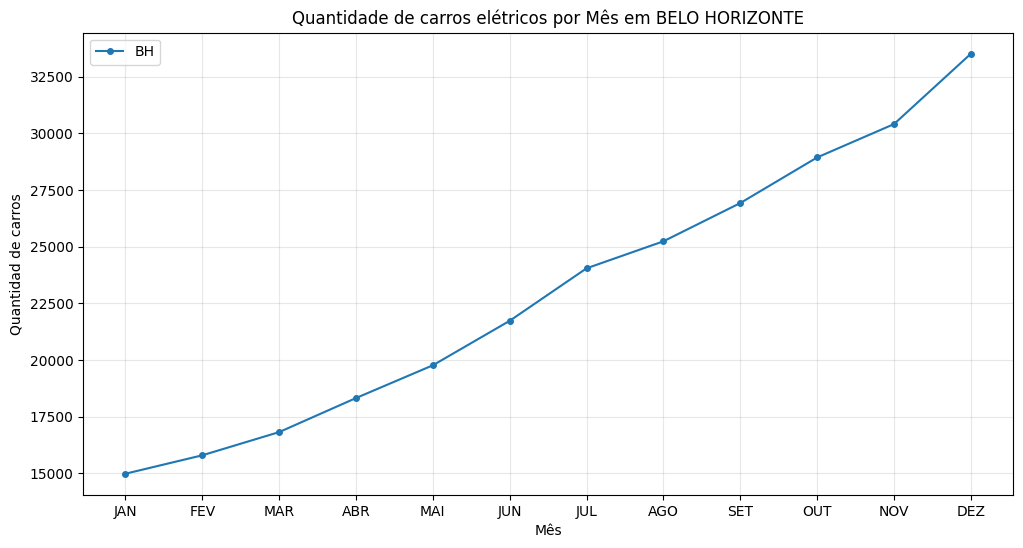

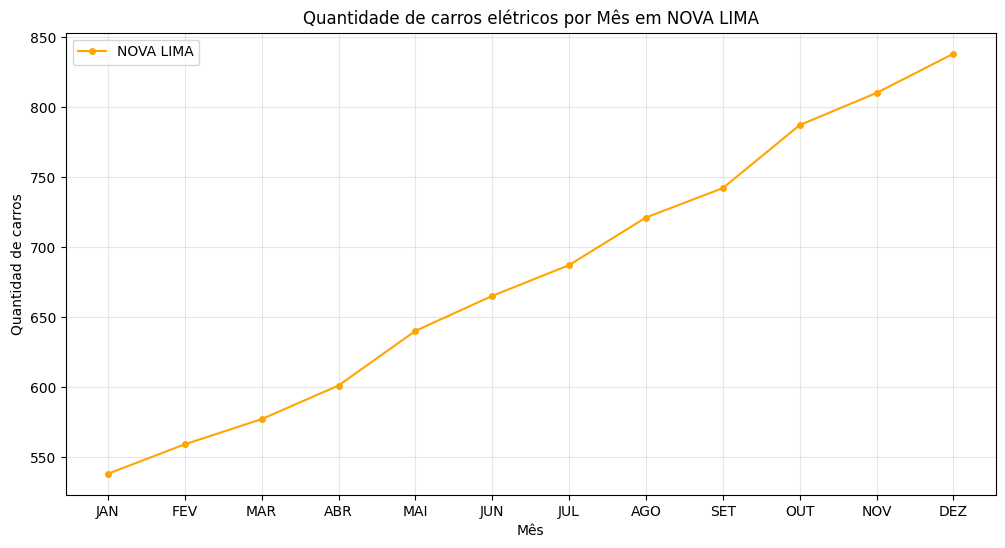

In [30]:
# grafico da quantidade de carros por mes
# somar a quantidade de carros eletricos e hibridos em BH e Nova Lima
qtd_mes_bh = df_bh.groupby(by='mes')['qtd_veiculos'].sum()
qtd_mes_novalima = df_nova_lima.groupby(by='mes')['qtd_veiculos'].agg('sum')

# criar imagem
plt.figure(figsize=(12,6))

qtd_mes_bh.plot(kind='line', marker='o', markersize=4, label='BH')

meses=['JAN','FEV','MAR','ABR','MAI','JUN','JUL','AGO','SET','OUT','NOV','DEZ']

plt.title('Quantidade de carros elétricos por Mês em BELO HORIZONTE')
plt.xlabel('Mês')
plt.ylabel('Quantidad de carros')
plt.grid(True, alpha=0.3)
plt.xticks(ticks=range(1,13), labels=meses)
plt.legend()
plt.show()

# criar imagem
plt.figure(figsize=(12,6))

qtd_mes_novalima.plot(kind='line', marker='o', markersize=4, label='NOVA LIMA', color='orange')

meses=['JAN','FEV','MAR','ABR','MAI','JUN','JUL','AGO','SET','OUT','NOV','DEZ']

plt.title('Quantidade de carros elétricos por Mês em NOVA LIMA')
plt.xlabel('Mês')
plt.ylabel('Quantidad de carros')
plt.grid(True, alpha=0.3)
plt.xticks(ticks=range(1,13), labels=meses)
plt.legend()
plt.show()


## Construção de um modelo para predizer a frota de carros eletricos em BELO HORIZONTE


  BELO HORIZONTE — MINAS GERAIS
  Crescimento mensal estimado : +1,685.6 veículos/mês
  R²                          : 0.9891
  MAE                         : 486.1 veículos

  Projeção — próximos 6 meses:
     Mês 13 (JAN): 33,999 veículos
     Mês 14 (FEV): 35,684 veículos
     Mês 15 (MAR): 37,370 veículos
     Mês 16 (ABR): 39,056 veículos
     Mês 17 (MAI): 40,741 veículos
     Mês 18 (JUN): 42,427 veículos



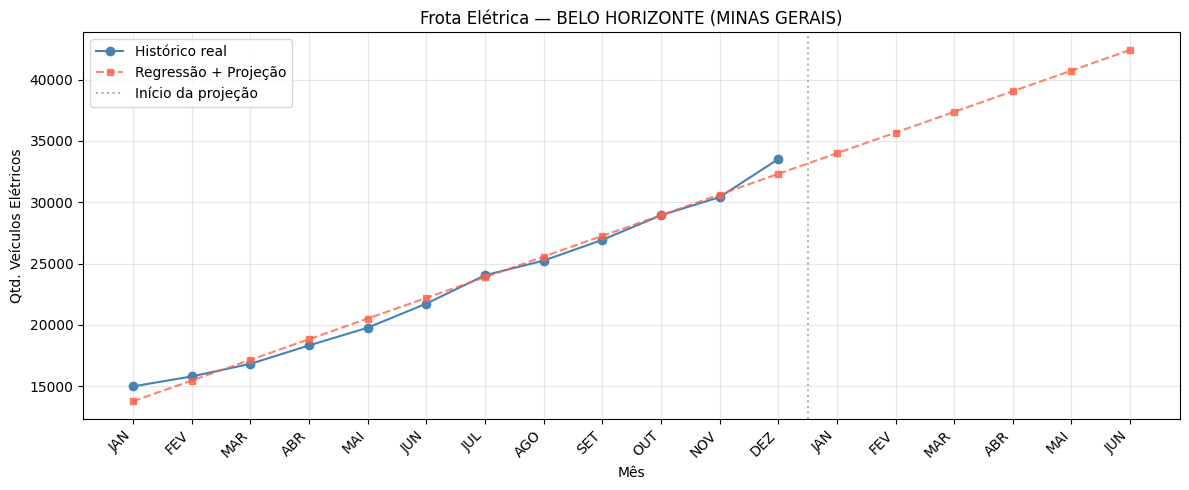

{'municipio': 'BELO HORIZONTE',
 'uf': 'MINAS GERAIS',
 'modelo': LinearRegression(),
 'r2': np.float64(0.9891489073776627),
 'mae': np.float64(486.10450660450607),
 'projecao': {13: 33999,
  14: 35684,
  15: 37370,
  16: 39056,
  17: 40741,
  18: 42427}}

In [31]:
# testando a função
prever_frota_eletrica(df_combustivel, 'Minas Gerais', 'belo horizonte')

## Teste dos gráficos para fazer um dashboard

In [32]:
# criar um df para saber a quantidade total de veiculos por uf
df_grouped_uf = df_combustivel.groupby(by='uf')['qtd_veiculos'].sum().reset_index()
df_grouped_uf

,uf,qtd_veiculos
0,ACRE,4528900
1,ALAGOAS,14487860
2,AMAPA,3243340
3,AMAZONAS,14913488
4,BAHIA,66670546
5,CEARA,48042747
6,DISTRITO FEDERAL,26409248
7,ESPIRITO SANTO,30870557
8,GOIAS,60468983
9,MARANHAO,27866036


In [33]:
# excluir as linhas que NÃO representam um estado ou Distrito Federal
df_grouped_uf = df_grouped_uf.drop([13,14,28], axis=0).reset_index(drop=True)

In [34]:
# criar df para saber a quantidade de carros elétricos e hibridos por estado
df_eletrico_hibrido = df_combustivel[df_combustivel['combustivel'].str.contains('ELETRICO|HIBRIDO')]
df_eletrico_hibrido_grouped_uf = df_eletrico_hibrido.groupby('uf')['qtd_veiculos'].sum().reset_index()
df_eletrico_hibrido_grouped_uf = df_eletrico_hibrido_grouped_uf.drop([26], axis=0).reset_index(drop=True)

In [35]:
# juntar os dois dfs
df_final_total_cars = pd.merge(df_grouped_uf, df_eletrico_hibrido_grouped_uf, on='uf')

In [36]:
# calcular a proporção de carros elétricos e hibridos sobre a frota total
df_final_total_cars.columns=['uf','qtd_total','qtd_ele_hib']
df_final_total_cars['proporcao %'] = (df_final_total_cars['qtd_ele_hib'] / df_final_total_cars['qtd_total'])*100
df_final_total_cars.rename(columns={'proporcao %':'proporcao_%'}, inplace=True)

In [37]:
df_final_total_cars.sort_values('proporcao_%', ascending=False).head(10)

,uf,qtd_total,qtd_ele_hib,proporcao_%
6,DISTRITO FEDERAL,26409248,513743,1.945315
23,SANTA CATARINA,78798234,463621,0.588365
7,ESPIRITO SANTO,30870557,174950,0.566721
24,SAO PAULO,418566908,2316332,0.553396
1,ALAGOAS,14487860,77305,0.533585
18,RIO DE JANEIRO,97557789,502547,0.515128
3,AMAZONAS,14913488,68360,0.458377
16,PERNAMBUCO,45994276,197026,0.428371
15,PARANA,112726501,448756,0.398093
19,RIO GRANDE DO NORTE,20070588,76876,0.383028


In [38]:
df_final_total_cars.to_csv('df_final_uf', index=False)